# Task 1 — Weekend Planner Agent

**Studio**
```
cd weekend_planner_studio
langgraph dev --no-reload
```
`https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024` 


In [1]:
%pip install -q -r requirements.txt python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys, os
sys.path.insert(0, ".")

from dotenv import load_dotenv
load_dotenv(".env")

assert os.environ.get("GOOGLE_API_KEY")
assert os.environ.get("TAVILY_API_KEY")

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.errors import GraphRecursionError
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START

from weekend_planner import (
    PlannerState,
    tools,
    llm,
    llm_with_tools,
    assistant,
    builder,
    SYSTEM_PROMPT,
)


c:\Users\najaf\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Draw the graph


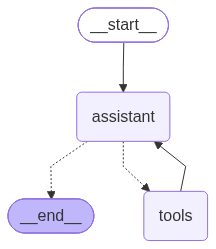

In [3]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 2. real conversation, 4+ steps


In [4]:
config = {"configurable": {"thread_id": "weekend-1"}, "recursion_limit": 15}

result = graph.invoke(
    {
        "messages": [HumanMessage(content="طفشانة اليوم بالخبر، اقترح علي شي يناسب مودي")],
        "mood": "bored",
        "city": "Khobar",
        "recommendations": {},
    },
    config,
)

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

طفشانة اليوم بالخبر، اقترح علي شي يناسب مودي
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather (xSsg1oLe)
 Call ID: xSsg1oLe
  Args:
    city: Khobar
  search_local_spot (NhqNIVvO)
 Call ID: NhqNIVvO
  Args:
    activity_type: fun indoor activity
    city: Khobar
  search_movie_or_game (HVMMXM3I)
 Call ID: HVMMXM3I
  Args:
    mood: bored
    media_type: movie
================================= Tool Message =================================
Name: get_weather

{"weather": {"time": "2026-08-03T18:45", "interval": 900, "temperature": 34.7, "windspeed": 5.2, "winddirection": 86, "is_day": 0, "weathercode": 0}}
================================= Tool Message =================================
Name: search_local_spot

{"spot_suggestion": [{"url": "https://www.tripadvisor.com/Attractions-g298545-Activities-zft11295-Al_Khobar_Eastern_Province.html", "title

## 3. Recursion / step limit

In [5]:
try:
    graph.invoke(
        {
            "messages": [HumanMessage(content="ودي فيلم ومطعم ولعبة وكتاب كلهم بنفس الوقت بالقطيف")],
            "mood": "overwhelmed",
            "city": "Qatif",
            "recommendations": {},
        },
        {"configurable": {"thread_id": "recursion-test"}, "recursion_limit": 3},
    )
except GraphRecursionError as e:
    print("GraphRecursionError caught as expected:", e)


GraphRecursionError caught as expected: Recursion limit of 3 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT


## 4. Break a tool on purpose

In [7]:
from tavily import TavilyClient

_real_key = os.environ["TAVILY_API_KEY"]
os.environ["TAVILY_API_KEY"] = "sk-invalid-broken-key"
broken_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

from langchain_core.tools import tool

@tool
def search_local_spot_broken(activity_type: str, city: str = "Dammam") -> dict:
    """Same as search_local_spot but intentionally broken for the demo."""
    query = f"{activity_type} in {city}, Eastern Province Saudi Arabia"
    result = broken_client.search(query=query, max_results=3)  # will raise
    return {"spot_suggestion": result.get("results", [])}

broken_tools = [search_local_spot_broken] + tools[1:]
broken_llm = llm.bind_tools(broken_tools)

broken_builder = StateGraph(PlannerState)
broken_builder.add_node(
    "assistant",
    lambda s: {"messages": [broken_llm.invoke([SystemMessage(content=SYSTEM_PROMPT)] + s["messages"])]},
)
broken_builder.add_node("tools", ToolNode(broken_tools, handle_tool_errors=True))  # handle_tool_errors=True by default
broken_builder.add_edge(START, "assistant")
broken_builder.add_conditional_edges("assistant", tools_condition)
broken_builder.add_edge("tools", "assistant")
broken_graph = broken_builder.compile(checkpointer=MemorySaver())

result = broken_graph.invoke(
    {
        "messages": [HumanMessage(content="ابغى مطعم بالدمام")],
        "mood": "hungry",
        "city": "Dammam",
        "recommendations": {},
    },
    {"configurable": {"thread_id": "broken-1"}, "recursion_limit": 10},
)
for m in result["messages"]:
    m.pretty_print()

os.environ["TAVILY_API_KEY"] = _real_key


================================ Human Message =================================

ابغى مطعم بالدمام
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather (90MZwsi5)
 Call ID: 90MZwsi5
  Args:
    city: Dammam
  search_local_spot_broken (8dCITgT6)
 Call ID: 8dCITgT6
  Args:
    activity_type: restaurant
    city: Dammam
================================= Tool Message =================================
Name: get_weather

{"weather": {"time": "2026-08-03T18:45", "interval": 900, "temperature": 36.2, "windspeed": 2.4, "winddirection": 81, "is_day": 0, "weathercode": 0}}
================================= Tool Message =================================
Name: search_local_spot_broken

Error: InvalidAPIKeyError('Unauthorized: missing or invalid API key.')
 Please fix your mistakes.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'الطقس الحالي في الدمام شديد الحرارة (**36.2°C**)، لذ

## 5. Swap to SqliteSaver — prove state survives a restart


In [3]:
sqlite_conn_str = "weekend_planner_state.sqlite"

with SqliteSaver.from_conn_string(sqlite_conn_str) as sqlite_memory:
    persistent_graph = builder.compile(checkpointer=sqlite_memory)

    config2 = {"configurable": {"thread_id": "persistent-1"}, "recursion_limit": 15}
    result = persistent_graph.invoke(
        {
            "messages": [HumanMessage(content="مافيه شي أسويه اليوم بالظهران، اقترحلي كتاب زين")],
            "mood": "bored",
            "city": "Dhahran",
            "recommendations": {},
        },
        config2,
    )
    for m in result["messages"]:
        m.pretty_print()
        
    state_after_restart = persistent_graph.get_state(config2)
    print(state_after_restart.values["messages"][-1].content[:200])

================================ Human Message =================================

مافيه شي أسويه اليوم بالظهران، اقترحلي كتاب زين
================================== Ai Message ==================================

[]
Tool Calls:
  get_book_recommendation (62yIb6tP)
 Call ID: 62yIb6tP
  Args:
    topic: fiction
  get_weather (CU2nnaLu)
 Call ID: CU2nnaLu
  Args:
    city: Dhahran
  search_local_spot (hsoxTYNO)
 Call ID: hsoxTYNO
  Args:
    city: Dhahran
    activity_type: quiet cafe or library
================================= Tool Message =================================
Name: get_book_recommendation

{"book_suggestion": [{"title": "Pride and Prejudice", "authors": ["Jane Austen"]}, {"title": "Alice's Adventures in Wonderland", "authors": ["Lewis Carroll"]}, {"title": "A Christmas Carol", "authors": ["Charles Dickens"]}]}
================================= Tool Message =================================
Name: get_weather

{"weather": {"time": "2026-08-03T18:45", "interval": 900, "tempera

## 6. Notes

- **What the reducer (`merge_recommendations`) does:** It merges the recommendations dict
  instead of overwriting it (`existing.update(new)`), so if more than one tool writes to the
  same field in the same step or across consecutive steps, no recommendation is lost in
  favor of another.

- **Trimming strategy I chose and why:** Trimming on the last N messages
  (`trim_messages` with `strategy="last"`), not summarization. I chose this because a
  "mood -> recommendation" conversation is usually short (5-10 messages), so there's no
  need to pay for an extra model call just to summarize. The cost: if the user returns to
  the same thread after a long time, older context gets dropped instead of summarized —
  an acceptable trade-off for a conversation this size.

- **What the agent did when the tool broke:** After setting `handle_tool_errors=True` on
  the ToolNode, the broken tool (`search_local_spot_broken`) returned an error message
  (`InvalidAPIKeyError`) as `ToolMessage` content instead of raising an exception that
  crashes the program. The agent read the error, apologized specifically for the
  restaurant part, and suggested alternatives (movie / game / book) instead of stopping
  entirely — a smarter recovery than just retrying.

- **Additional thing we discovered:** In the current version of LangGraph, `ToolNode`
  does not catch all exceptions automatically by default — you have to explicitly set
  `handle_tool_errors=True` so the error is turned into a message the model can read and
  react to.

- **LangSmith trace link for a run that took 4+ steps:** [paste the trace link for the
  Section 2 run from smith.langchain.com here]
